In [7]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt  
import seaborn as sns          
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris                      
from sklearn.preprocessing import StandardScaler        

In [8]:
iris = load_iris()                    
df = pd.DataFrame(iris.data, columns=iris.feature_names)                  

In [9]:
X = df[['sepal length (cm)' , 'sepal width (cm)']].values                  

In [10]:
df.head()     

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
scaler = StandardScaler()                    
X_scaled = scaler.fit_transform(X)    

In [12]:
kmeans = KMeans(n_clusters=5 ,
                init = 'k-means++',random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)         

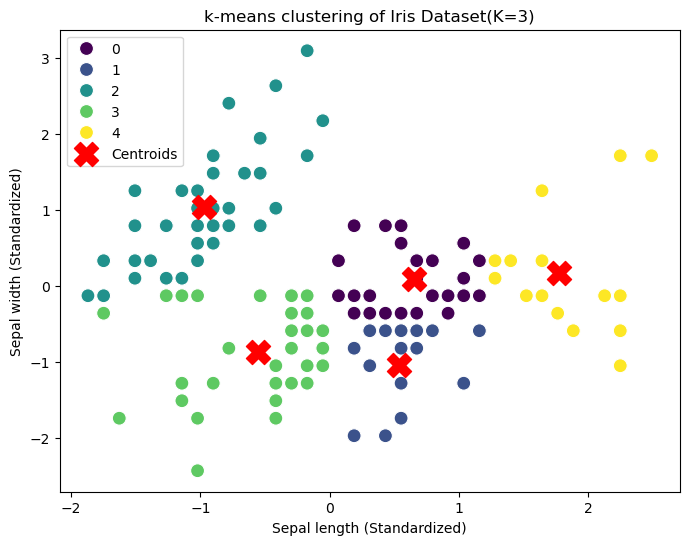

In [13]:
plt.figure(figsize=(8,6))                                           
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],hue=y_kmeans,            
                palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=300, c='red' , marker='X', label='Centroids')
plt.xlabel('Sepal length (Standardized)')
plt.ylabel('Sepal width (Standardized)')
plt.title('k-means clustering of Iris Dataset(K=3)')
plt.legend()
plt.show()


In [14]:
wcss = []
k_values = range(1,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k , random_state=42 , n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [20]:
X = np.array([[2,3,4],[3,5,6],[5,9,8],[6,9,11],[7,10,13]])

In [22]:
mean_X=np.mean(X, axis=0)
print(mean_X)

[4.6 7.2 8.4]


In [23]:
X_centered = X - mean_X
print(X_centered)

[[-2.6 -4.2 -4.4]
 [-1.6 -2.2 -2.4]
 [ 0.4  1.8 -0.4]
 [ 1.4  1.8  2.6]
 [ 2.4  2.8  4.6]]


In [24]:
cov_matrix = np.cov(X_centered,rowvar = False)
print(cov_matrix)

[[ 4.3   6.1   7.45]
 [ 6.1   9.2  10.15]
 [ 7.45 10.15 13.3 ]]


In [25]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues)

[2.58976604e+01 7.27999875e-03 8.95059579e-01]


In [26]:
print(eigenvectors)

[[ 0.40718957  0.91333852 -0.0030676 ]
 [ 0.57842206 -0.26047165 -0.77303456]
 [ 0.70684126 -0.31299724  0.63435649]]


In [28]:
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:,sorted_indices]

In [30]:
X_tramsformed_1 = X_centered @ eigenvectors[:,0]
X_tramsformed_2 = X_centered @ eigenvectors[:,:2]

In [31]:
print("Transformed Data (3 to 1):")
print(X_tramsformed_1)
print("\nTranformed Data (3 to 2):")
print(X_tramsformed_2)

Transformed Data (3 to 1):
[-6.5981671  -3.62045088  0.92129904  3.4490124   5.84830655]

Tranformed Data (3 to 2):
[[-6.59816710e+00  9.64886504e-02]
 [-3.62045088e+00 -1.37110616e-01]
 [ 9.21299035e-01  2.16853384e-02]
 [ 3.44901240e+00 -3.96787680e-03]
 [ 5.84830655e+00  2.29045043e-02]]


In [32]:
wine = pd.read_csv("winequality-red.csv")

In [33]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
